# Label Data
This notebook is made to label the data. To create correct labels for each of the testing experimental data examples in order to ensure the corectness of the runs.

In [1]:
import numpy as np
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath('..'))

from script.helper_methods import data_preprocessing as dp
from script.helper_methods import data_visualization as dv


In [2]:
def prepare(df, columns, name):

    columns_to_remove = [col for col in df.columns if col not in columns]
    df = df.drop(columns=columns_to_remove) 

    dp.create_target_column(df)
    dp.create_future_target(df)

    print(f"Dataset {name} with shape: {df.shape}")

    return df

In [ ]:
def save_labeled_data(df, name):
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
    LABELED_PATH = os.path.join(BASE_PATH, 'data', 'labeled')
    if not os.path.exists(LABELED_PATH):
        os.makedirs(LABELED_PATH)
    output_path = os.path.join(LABELED_PATH, f'labeled_{name}.csv')
    df.to_csv(output_path, index=True)
    print(f"Labeled data saved to {output_path}")

In [4]:
def set_default_plug(df):
    dp.create_target_column(df) # Makes plug = 1/0 column, based on flow/pressure threshold
    dp.create_future_target(df)

In [5]:
def set_no_plug(df):
    df['Plug'] = 0
    df['Plug_future'] = 0

In [6]:
def show_info(df):
    print(f"Dataset columns: {df.columns.tolist()}")
    return df.head()

In [7]:
def set_plug_at_time(df, time_start, time_end):
    # find first plug
    start_time = f'1900-01-01 {time_start}.330000'
    end_time = f'1900-01-01 {time_end}.330000'

    # set plug column
    if 'Plug' not in df.columns:
        df['Plug'] = 0  
    df['Plug'] = np.where((df.index >= start_time) & (df.index <= end_time), 1, df['Plug'])

In [8]:
# Load the data
print("Loading datasets...")
dataset1 = dp.load_raw_data()
dataset2 = dp.load_raw_data(path="../data/raw_data/data2/*.csv")
dataset3 = dp.load_raw_data(path="../data/raw_data/data3/*.csv")
dataset4 = dp.load_raw_data(path="../data/raw_data/data4/*.csv")
dataset5 = dp.load_raw_data(path="../data/raw_data/data5/*.csv")
dataset6 = dp.load_raw_data(path="../data/raw_data/data6/*.csv")
dataset7 = dp.load_raw_data(path="../data/raw_data/data7/*.csv")
dataset8 = dp.load_raw_data(path="../data/raw_data/data8/*.csv")
dataset9 = dp.load_raw_data(path="../data/raw_data/data9/*.csv")
dataset10 = dp.load_raw_data(path="../data/raw_data/data10/*.csv")
dataset11 = dp.load_raw_data(path="../data/raw_data/data11/*.csv")
dataset12 = dp.load_raw_data(path="../data/raw_data/data12/*.csv")
print("Datasets loaded.")

# columns = dataset1.columns.tolist()
# print("Columns to keep:", columns)

# dataset2 = prepare(dataset2, columns, "2")
# dataset5 = prepare(dataset5, columns, "5")
# dataset6 = prepare(dataset6, columns, "6")
# dataset8 = prepare(dataset8, columns, "8")

Loading datasets...
Datasets loaded.


In [9]:
dataset1.head(5)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


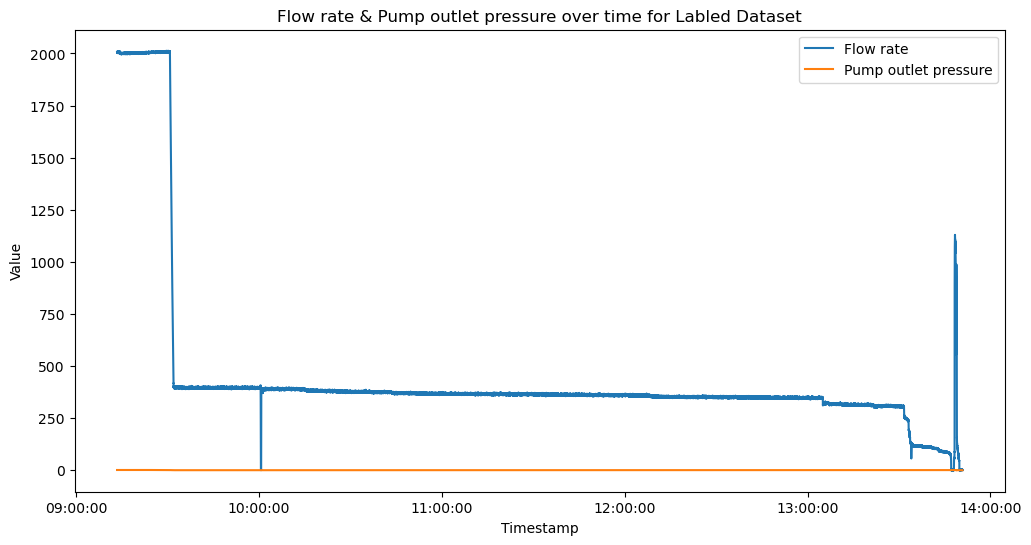

In [10]:
dv.visualize_flow_rate(dataset1, name="Labled Dataset")

## For each dataset look at it and label it

⚙️ Flow threshold set to: 327.32


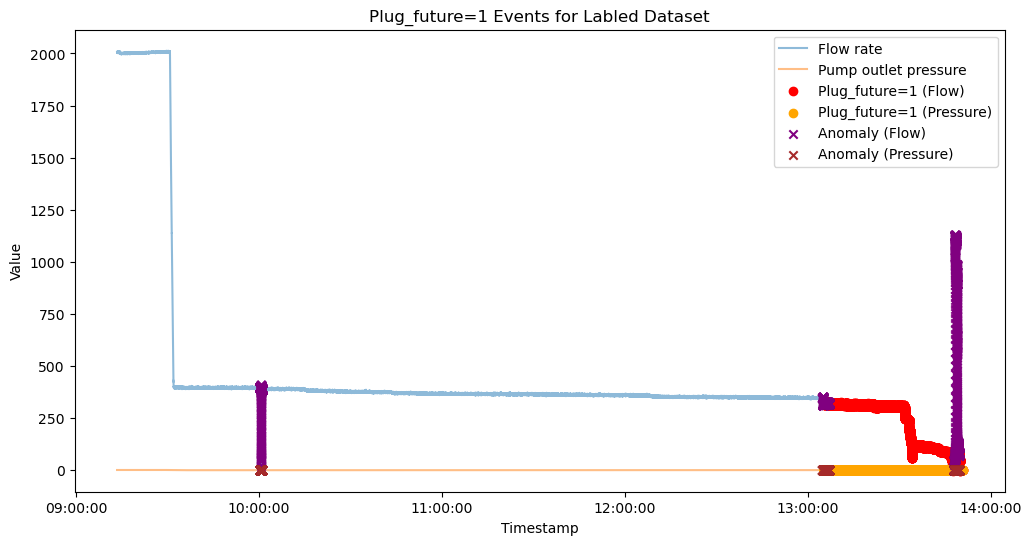

In [11]:
set_default_plug(dataset1)
dv.visualize_plug_event(dataset1, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 2

⚙️ Flow threshold set to: 346.84


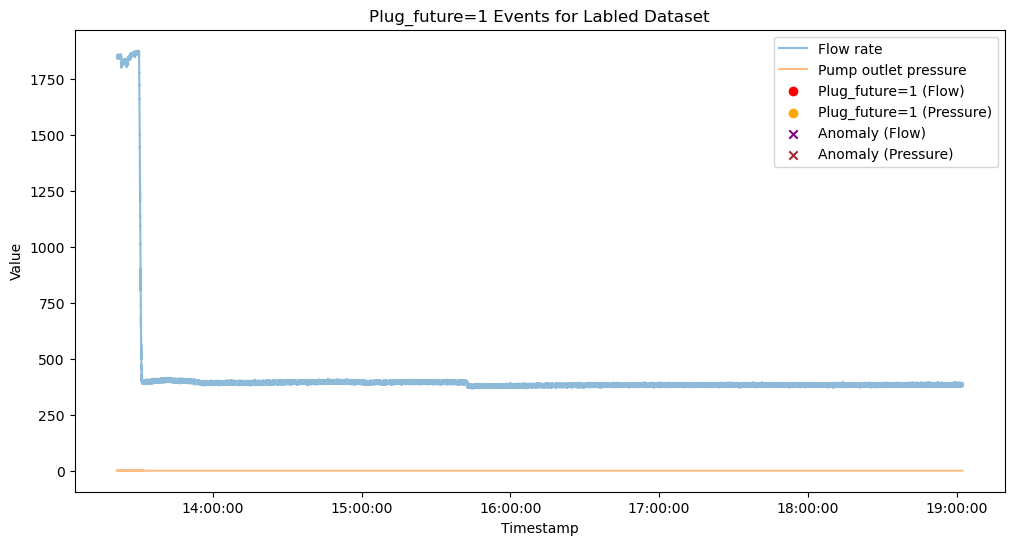

In [12]:
set_default_plug(dataset2)
dv.visualize_plug_event(dataset2, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 3 ????????

In [13]:
show_info(dataset3)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']


,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
1900-01-01 10:08:28.347,0.759556,0.000932,0.212329,1561.091208,7.280965,-2.381982,-0.025701,21.950240,0.241412,0.649763,0.230938,1.075645,0.017048,0.083666,0.005487,11.664282
1900-01-01 10:08:28.846,0.760145,0.000721,0.213470,1560.987274,7.231516,-2.370934,-0.125659,21.969181,0.269339,0.664583,0.236032,1.083438,0.016058,0.090984,0.005661,12.519271
1900-01-01 10:08:29.350,0.758179,0.000997,0.213269,1562.163933,7.182435,-2.299218,-0.214808,21.954802,0.257213,0.630675,0.242421,1.112259,0.016666,0.095589,0.005747,11.097039
1900-01-01 10:08:29.848,0.760242,0.000642,0.212117,1563.040239,7.017590,-2.263474,-0.313047,21.937244,0.279101,0.723726,0.245817,1.062527,0.016441,0.111216,0.005620,11.240369
1900-01-01 10:08:30.347,0.759019,0.000795,0.212366,1561.894331,7.095533,-2.231526,-0.370821,21.960763,0.266585,0.612376,0.251867,1.087259,0.016192,0.112690,0.005541,11.301572


⚙️ Flow threshold set to: 1128.58


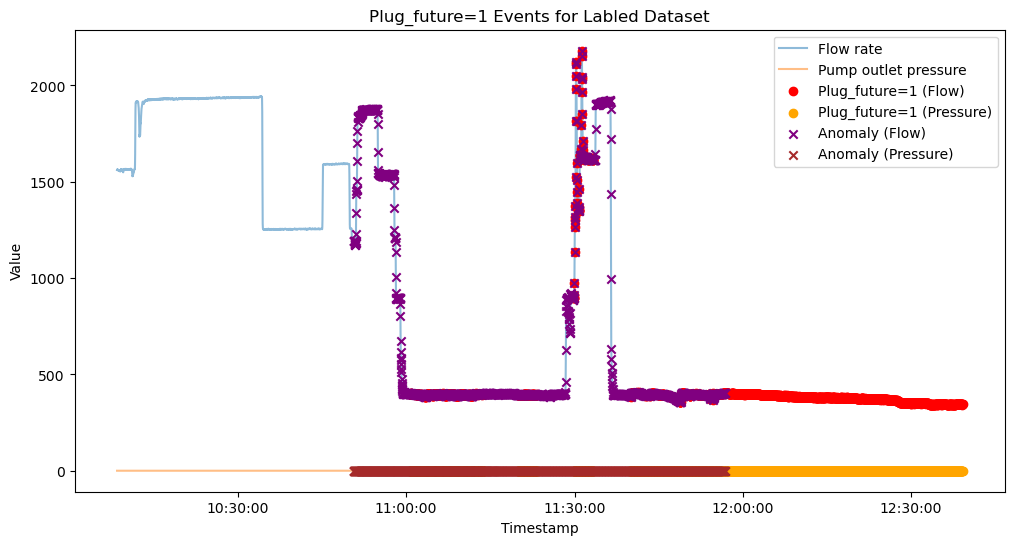

In [14]:
set_default_plug(dataset3)
dv.visualize_plug_event(dataset3, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Data 4
No blockage

In [15]:
show_info(dataset4)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 15:14:08.717,21.289102,-7.686529,21.978412,-7.887004,0.234429,0.241925,0.430600,1.023696
1900-01-01 15:14:09.717,21.273088,-7.692305,21.964366,-7.885036,0.233763,0.241222,0.430003,1.000122
1900-01-01 15:14:10.717,21.281620,-7.690073,21.969485,-7.881623,0.233689,0.240896,0.431041,0.957688
1900-01-01 15:14:11.717,21.273613,-7.691123,21.965547,-7.872829,0.234797,0.243133,0.432006,0.849248
1900-01-01 15:14:12.717,21.278076,-7.700311,21.966991,-7.865742,0.234015,0.241999,0.430940,0.594648


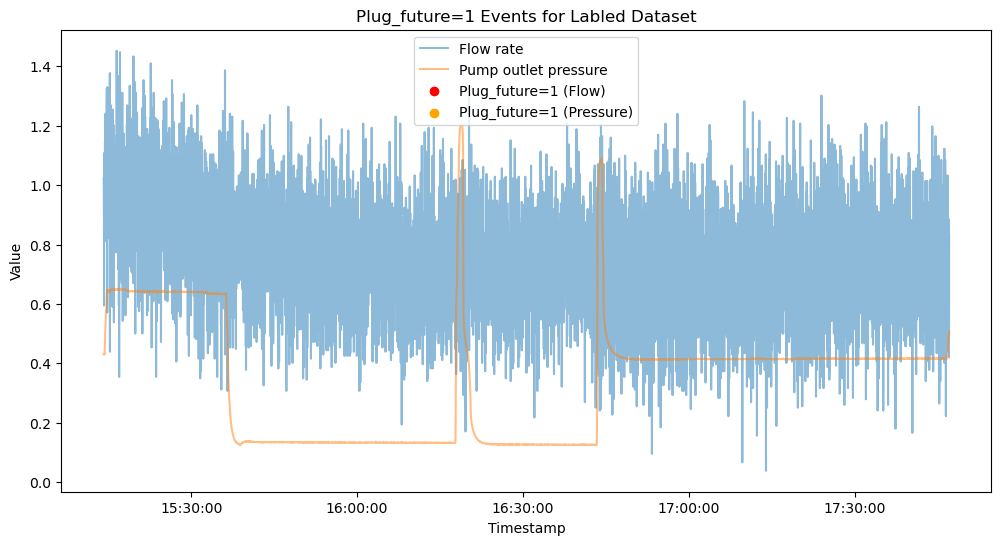

In [16]:
set_no_plug(dataset4)
dv.visualize_plug_event(dataset4, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 5
Plug at 70 mins

In [17]:
show_info(dataset5)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']


,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
1900-01-01 11:07:40.450,0.652198,0.002561,0.216821,1197.850879,21.892479,-6.356868,-5.944637,-5.825225,0.244302,0.724920,0.213840,0.282836,0.018072,0.081870,0.004608,11.816486
1900-01-01 11:07:40.949,0.650550,0.002615,0.216269,1196.577000,21.904315,-6.356699,-5.943776,-5.804735,0.247066,0.757112,0.213078,0.283316,0.018405,0.080948,0.004419,11.061990
1900-01-01 11:07:41.453,0.651297,0.002800,0.215000,1192.332124,21.883107,-6.318099,-5.939004,-5.823056,0.254509,0.747501,0.219824,0.281944,0.018836,0.079520,0.004669,11.592692
1900-01-01 11:07:41.949,0.651998,0.002484,0.215635,1189.644134,21.905444,-6.318045,-5.936312,-5.803727,0.245705,0.761614,0.199970,0.279040,0.018200,0.080179,0.005180,11.194329
1900-01-01 11:07:42.453,0.656662,0.002737,0.219138,1189.778269,21.904721,-6.317839,-5.936660,-5.802740,0.244332,0.777832,0.206917,0.256907,0.018160,0.082592,0.004637,10.450238


In [18]:
# Find 70 minutes marker
start_time = dataset5.index.min()
marker_time = start_time + pd.Timedelta(minutes=70)
print(f"70 minutes marker timestamp: {marker_time}")

# set plug
dataset5['Plug'] = np.where(dataset5.index >= marker_time, 1, 0)
dp.create_future_target(dataset5)

70 minutes marker timestamp: 1900-01-01 12:17:40.450000


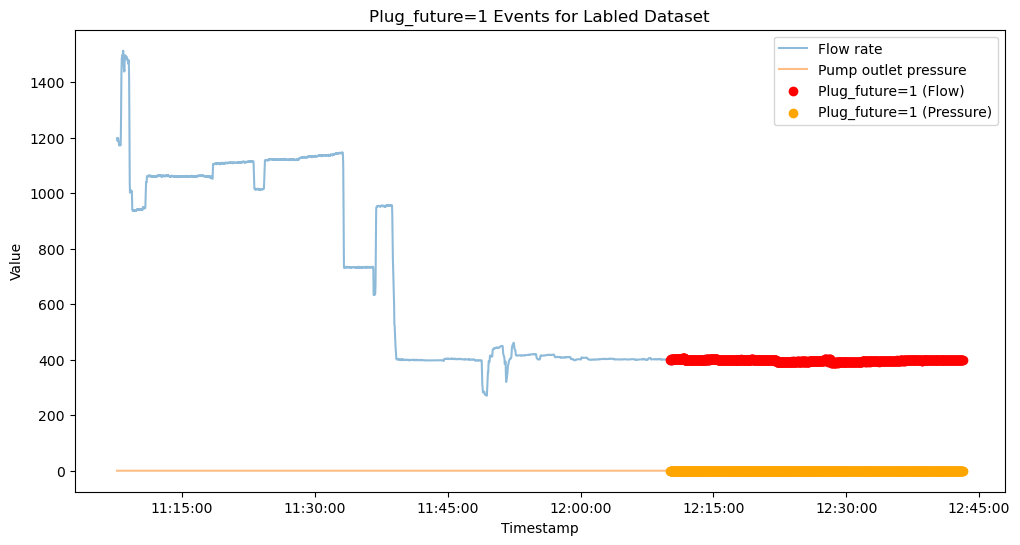

In [19]:
dv.visualize_plug_event(dataset5, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 6
No plug - manual adjustments

In [20]:
show_info(dataset6)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']


,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
1900-01-01 11:44:15.469,-0.000953,0.000388,-0.002267,0.751986,22.254471,23.476945,22.523866,23.597269,0.204264,0.149411,0.118877,0.198649,0.013532,0.004897,0.005212,3.493279
1900-01-01 11:44:15.973,-0.000864,0.000299,-0.002195,0.701742,22.275812,23.469334,22.524412,23.596239,0.177941,0.149632,0.125484,0.187145,0.013116,0.005382,0.005186,3.441039
1900-01-01 11:44:16.474,-0.000679,0.000365,-0.002517,0.576880,22.277582,23.477137,22.522801,23.594067,0.177954,0.144385,0.118495,0.207919,0.012904,0.005223,0.005290,3.247005
1900-01-01 11:44:16.970,-0.000762,0.000494,-0.002137,0.809020,22.254735,23.465830,22.521484,23.593299,0.201474,0.144347,0.118798,0.196353,0.014150,0.005094,0.005319,2.960882
1900-01-01 11:44:17.469,-0.000832,0.000511,-0.002550,0.612487,22.248877,23.471958,22.525223,23.593919,0.214081,0.154330,0.122937,0.168015,0.014046,0.004871,0.005322,3.166494


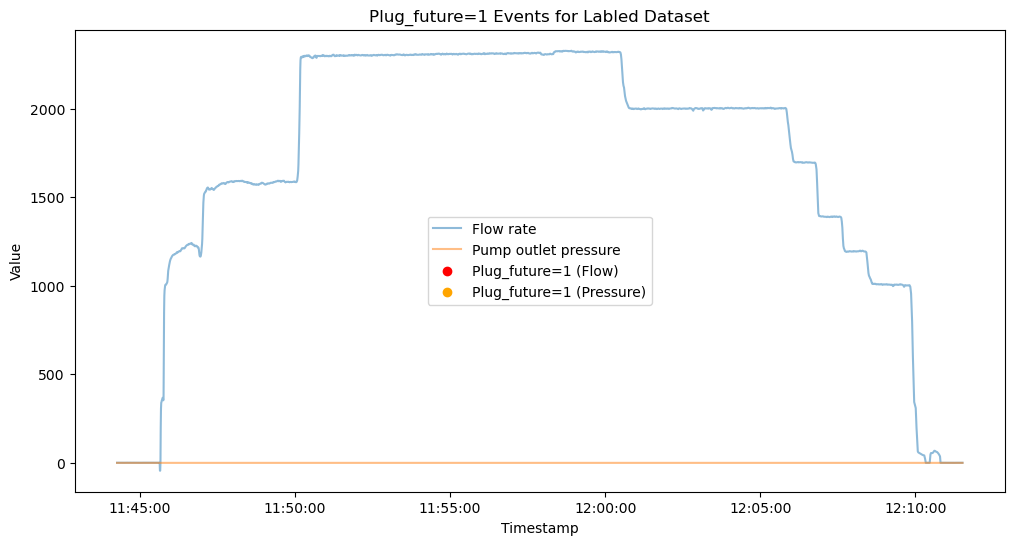

In [21]:
set_no_plug(dataset6)
dv.visualize_plug_event(dataset6, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 7
No plug

In [22]:
show_info(dataset7)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 11:05:25.279,-4.685960,-4.767171,24.552289,-4.856727,0.638409,0.981819,1.100481,2002.167506
1900-01-01 11:05:26.279,-4.648682,-4.732914,24.528003,-4.837302,0.639438,0.983993,1.102310,2000.616334
1900-01-01 11:05:27.279,-4.679922,-4.736195,24.537323,-4.852527,0.641821,0.987001,1.105452,2000.390024
1900-01-01 11:05:28.279,-4.664958,-4.732389,24.538505,-4.827196,0.641307,0.986917,1.106306,2001.936481
1900-01-01 11:05:29.279,-4.651307,-4.724776,24.532991,-4.832052,0.640892,0.984943,1.103081,2001.144393


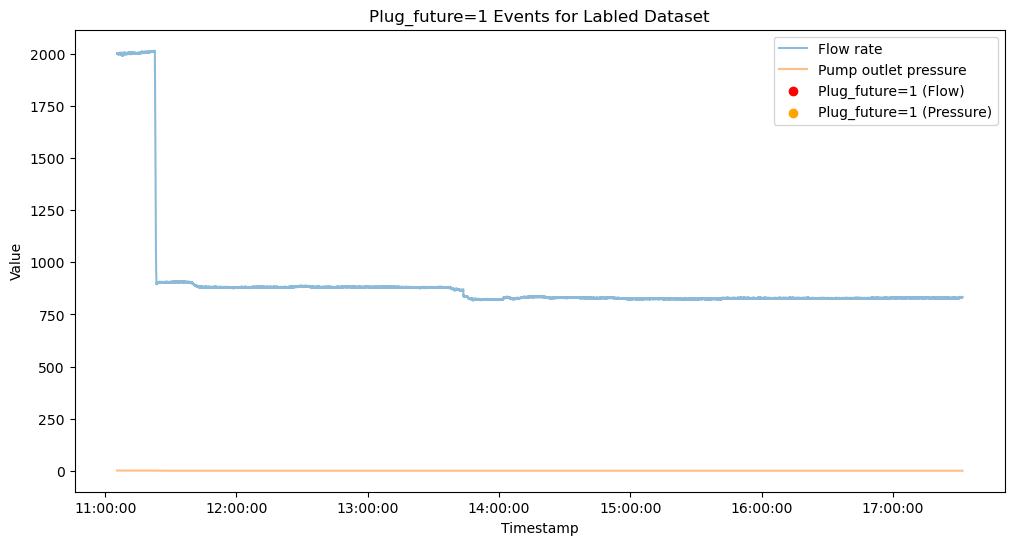

In [23]:
set_no_plug(dataset7)
dv.visualize_plug_event(dataset7, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 8
Loop block - 15:11:12-15:16:10  - first run
orifice block - 15:19:56-15:24:32 - second run

In [24]:
show_info(dataset8)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:51:06.330,22.084809,23.496209,22.423823,22.306702,-0.001149,-0.000124,0.037587,1.127421
1900-01-01 14:51:07.330,22.086515,23.472452,22.425135,22.309064,-0.001296,-0.000103,0.037991,1.004836
1900-01-01 14:51:08.330,22.086122,23.481640,22.424741,22.308014,-0.001181,-0.000035,0.038083,0.948259
1900-01-01 14:51:09.330,22.088222,23.485972,22.425135,22.310245,-0.000960,0.000044,0.038221,1.103847
1900-01-01 14:51:10.330,22.084546,23.490697,22.424085,22.312214,-0.001223,0.000075,0.037973,1.094418


In [25]:
# find first plug
start_time_first_plug = '15:11:12'
end_time_first_plug = '15:16:10'

start_time_second_plug = '15:19:56'
end_time_second_plug = '15:24:32'

set_plug_at_time(dataset8, start_time_first_plug, end_time_first_plug)
set_plug_at_time(dataset8, start_time_second_plug, end_time_second_plug)
dp.create_future_target(dataset8)

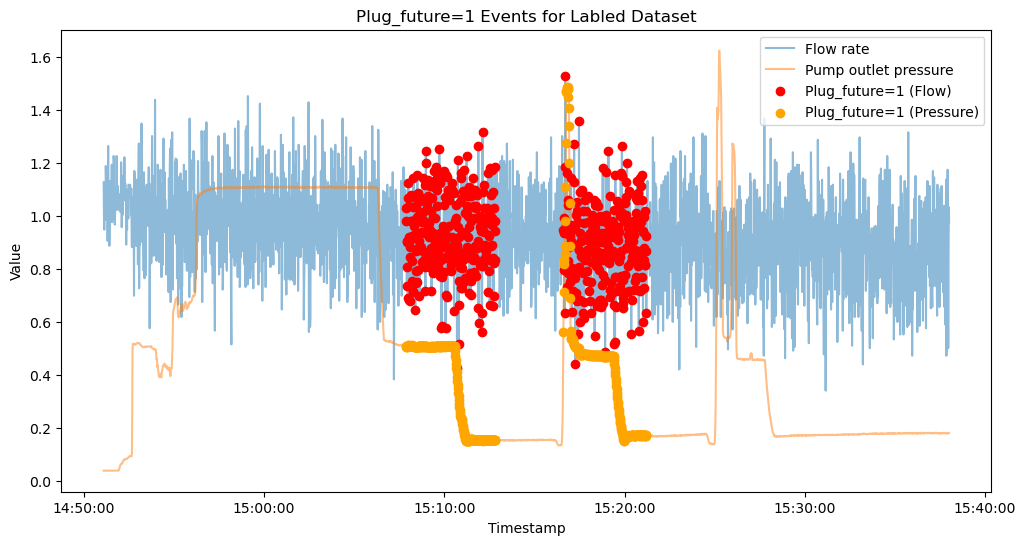

In [26]:
dv.visualize_plug_event(dataset8, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 9
13:15:49-13:44:06 - test section block

In [27]:
show_info(dataset9)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 12:50:22.552,22.105023,22.784024,22.143948,21.820424,-0.001144,0.001010,0.030614,0.962403
1900-01-01 12:50:23.552,22.103317,22.764467,22.139616,21.815305,-0.001050,0.001136,0.030568,1.070844
1900-01-01 12:50:24.552,22.107123,22.770242,22.134496,21.820030,-0.001286,0.001178,0.030586,1.136851
1900-01-01 12:50:25.552,22.105286,22.778642,22.133052,21.819111,-0.001212,0.001152,0.030779,1.150995
1900-01-01 12:50:26.552,22.104104,22.769192,22.133183,21.818061,-0.001223,0.000873,0.030467,1.188714


In [28]:
set_plug_at_time(dataset9, '13:15:49', '13:44:06')
dp.create_future_target(dataset9)

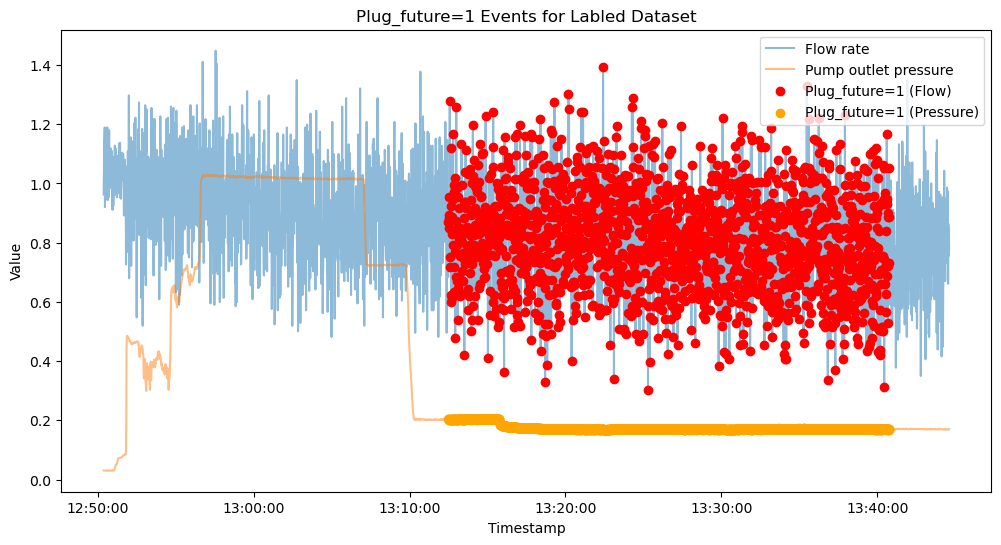

In [29]:
dv.visualize_plug_event(dataset9, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 10
3 runs

13:57:15 - 13:59:21 -> Run 1 - loop blockage

14:01:48 - 14:06:57 -> Run 2 - orifice blockage

14:27:16 - 14:31:41 -> Run 3 - no block

In [30]:
show_info(dataset10)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:55:39.663,21.999620,-2.009256,24.051350,-2.157328,0.354064,0.366056,0.646015,0.622937
1900-01-01 13:55:40.663,21.992532,-2.007550,24.048330,-2.145516,0.354553,0.366539,0.646474,1.042555
1900-01-01 13:55:41.663,21.996995,-2.005187,24.044261,-2.144203,0.354437,0.365835,0.645950,0.740807
1900-01-01 13:55:42.663,21.989644,-2.004662,24.046624,-2.144203,0.354327,0.365914,0.646400,1.165140
1900-01-01 13:55:43.663,21.976124,-2.009256,24.031921,-2.149060,0.354642,0.365273,0.646134,0.886966


In [31]:
set_plug_at_time(dataset10, '13:57:15', '13:59:21')
set_plug_at_time(dataset10, '14:01:48', '14:06:57')
dp.create_future_target(dataset10)

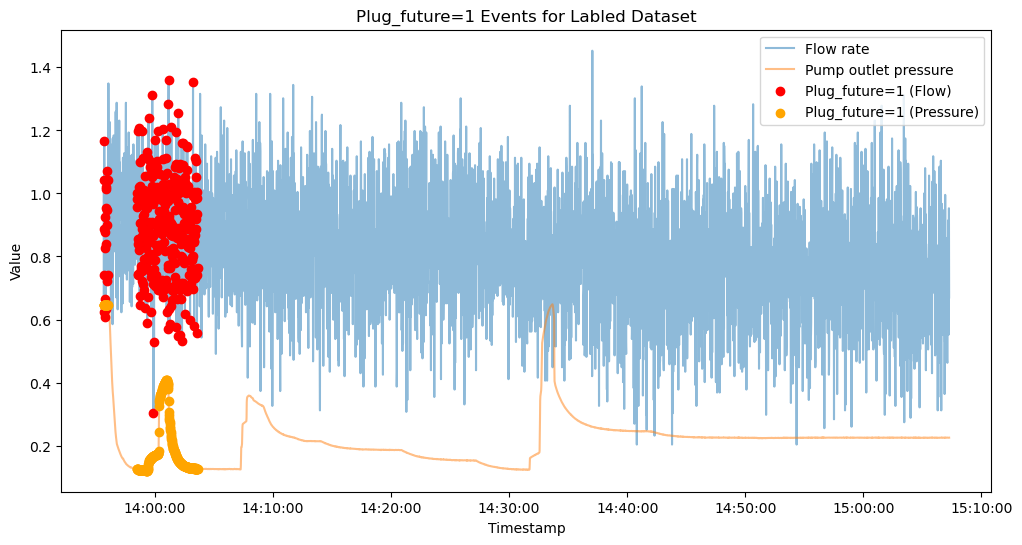

In [32]:
dv.visualize_plug_event(dataset10, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 11

4 runs

Time of runs:

14:33:05 – 15:14:26 -> Run 1

15:20:20 – 15:28:59 -> Run 2 - block

15:33:24 – 15:44:06 -> Run 3 - block

15:49:03 - 16:08:07 -> Run 4 - block

In [33]:
show_info(dataset11)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:56:49.628,21.208376,-6.971719,23.120621,-7.084154,0.251241,0.261635,0.463390,3.786573
1900-01-01 13:56:50.628,21.208376,-6.971456,23.122066,-7.081135,0.251745,0.262880,0.463335,3.720566
1900-01-01 13:56:51.628,21.223209,-6.960037,23.127054,-7.081267,0.251136,0.261336,0.462848,3.687562
1900-01-01 13:56:52.628,21.197350,-6.963318,23.122197,-7.075360,0.252407,0.262402,0.463518,3.711136
1900-01-01 13:56:53.628,21.198794,-6.957412,23.116027,-7.074573,0.252134,0.262449,0.463188,3.692277


In [34]:
set_plug_at_time(dataset11, '15:20:20', '15:28:59')
set_plug_at_time(dataset11, '15:33:24', '15:44:06')
set_plug_at_time(dataset11, '15:49:03', '16:08:07')
dp.create_future_target(dataset11)

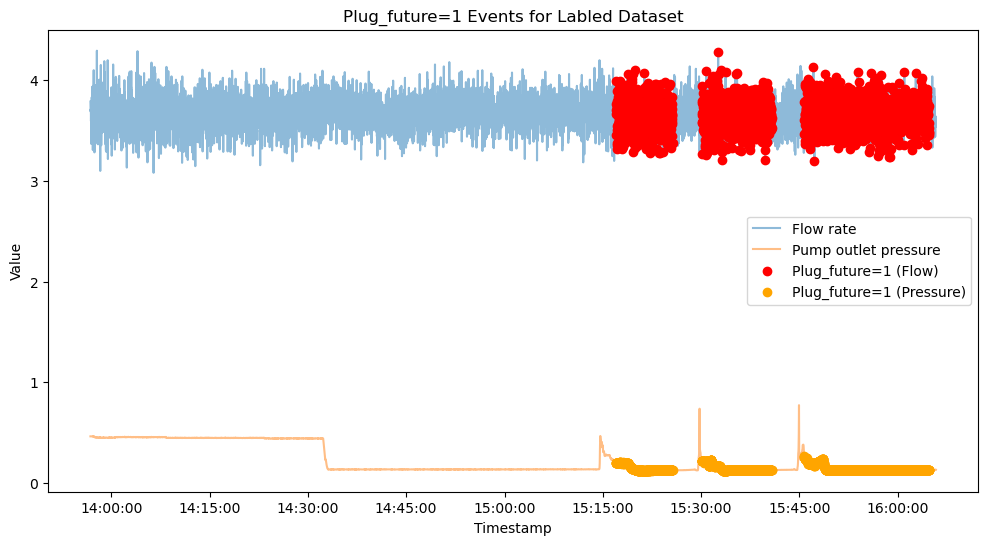

In [35]:
dv.visualize_plug_event(dataset11, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 12
3 runs

Time-codes:

13:53:03 – 15:02:50

15:08:37 – 16:08:03

16:15:39 - 17:03:21 Loop blockage

In [36]:
show_info(dataset12)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:35:02.939,21.251430,-5.328284,22.052975,-5.492760,0.255420,0.269122,0.475168,1.683769
1900-01-01 13:35:03.939,21.254187,-5.318308,22.060589,-5.488297,0.254701,0.268671,0.474984,1.415025
1900-01-01 13:35:04.939,21.252086,-5.320540,22.060195,-5.481210,0.255132,0.268225,0.475122,1.443314
1900-01-01 13:35:05.939,21.230953,-5.324215,22.058620,-5.481341,0.254554,0.268639,0.474617,1.396165
1900-01-01 13:35:06.939,21.234760,-5.317258,22.063477,-5.478191,0.256155,0.269616,0.475710,1.853502


In [37]:
set_plug_at_time(dataset12, '16:15:39', '17:03:21')
dp.create_future_target(dataset12)

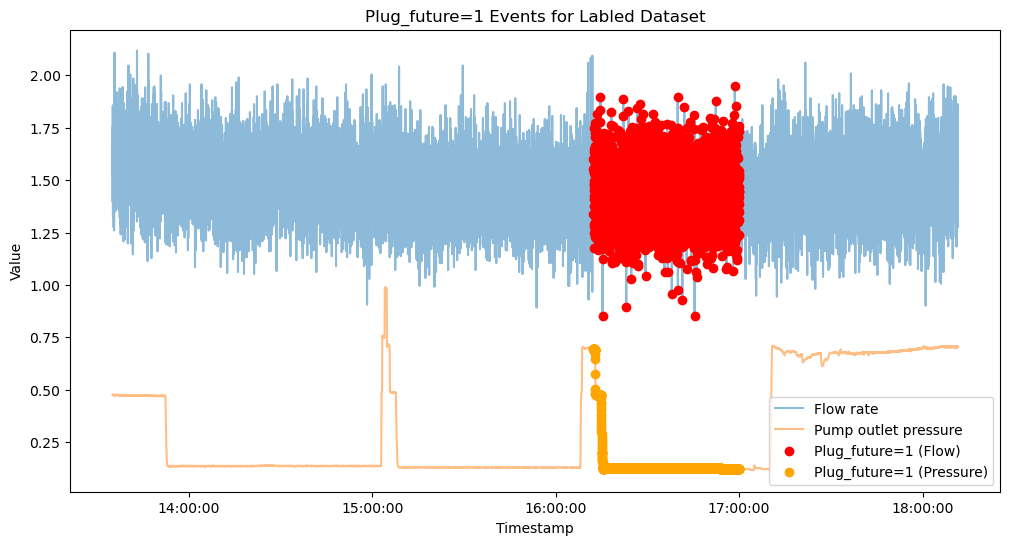

In [38]:
dv.visualize_plug_event(dataset12, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Save data to new csv files
Save data to new csv files with the lables to be used later in model traning. 

In [39]:
save_labeled_data(dataset1, "data1")
save_labeled_data(dataset2, "data2")
save_labeled_data(dataset3, "data3")
save_labeled_data(dataset4, "data4")
save_labeled_data(dataset5, "data5")
save_labeled_data(dataset6, "data6")
save_labeled_data(dataset7, "data7")
save_labeled_data(dataset8, "data8")
save_labeled_data(dataset9, "data9")
save_labeled_data(dataset10, "data10")
save_labeled_data(dataset11, "data11")
save_labeled_data(dataset12, "data12")

Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data1.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data2.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data3.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data4.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data5.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data6.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data7.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data8.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data9.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data10.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data11.csv
Labeled data saved 